## Goals

 To analyze the sales and profit performance of a retail company based on regions, product categories, customer segments, and discount strategies in order to identify the factors affecting profitability and provide data-driven business recommendations to improve overall profitability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')
sns.set_style('whitegrid')
sns.set_palette('Blues_r')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('SampleSuperstore.csv')

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
df.drop(columns=['Postal Code']).describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.shape

(9994, 13)

In [7]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(col, df[col].dtype)
        print(df[col].min(), df[col].max())
    else:
        print(col, df[col].dtype)
        print(df[col].unique())
    print()

Ship Mode object
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment object
['Consumer' 'Corporate' 'Home Office']

Country object
['United States']

City object
['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont'
 'Philadelphia' 'Orem' 'Houston' 'Richardson' 'Naperville' 'Melbourne'
 'Eagan' 'Westland' 'Dover' 'New Albany' 'New York City' 'Troy' 'Chicago'
 'Gilbert' 'Springfield' 'Jackson' 'Memphis' 'Decatur' 'Durham' 'Columbia'
 'Rochester' 'Minneapolis' 'Portland' 'Saint Paul' 'Aurora' 'Charlotte'
 'Orland Park' 'Urbandale' 'Columbus' 'Bristol' 'Wilmington' 'Bloomington'
 'Phoenix' 'Roseville' 'Independence' 'Pasadena' 'Newark' 'Franklin'
 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio' 'Monroe'
 'Fairfield' 'Grand Prairie' 'Redlands' 'Hamilton' 'Westfield' 'Akron'
 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin' 'Detroit'
 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Br

In [8]:
## Displays rows that are duplicates of a previous row
df.duplicated().sum()

np.int64(17)

In [9]:
# Delete Duplicates
df = df.drop_duplicates()

In [10]:
df.shape

(9977, 13)

In [11]:
#Shows the total number of missing values for every column
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## Exploratory Data Analysis of Retail Sales Performance

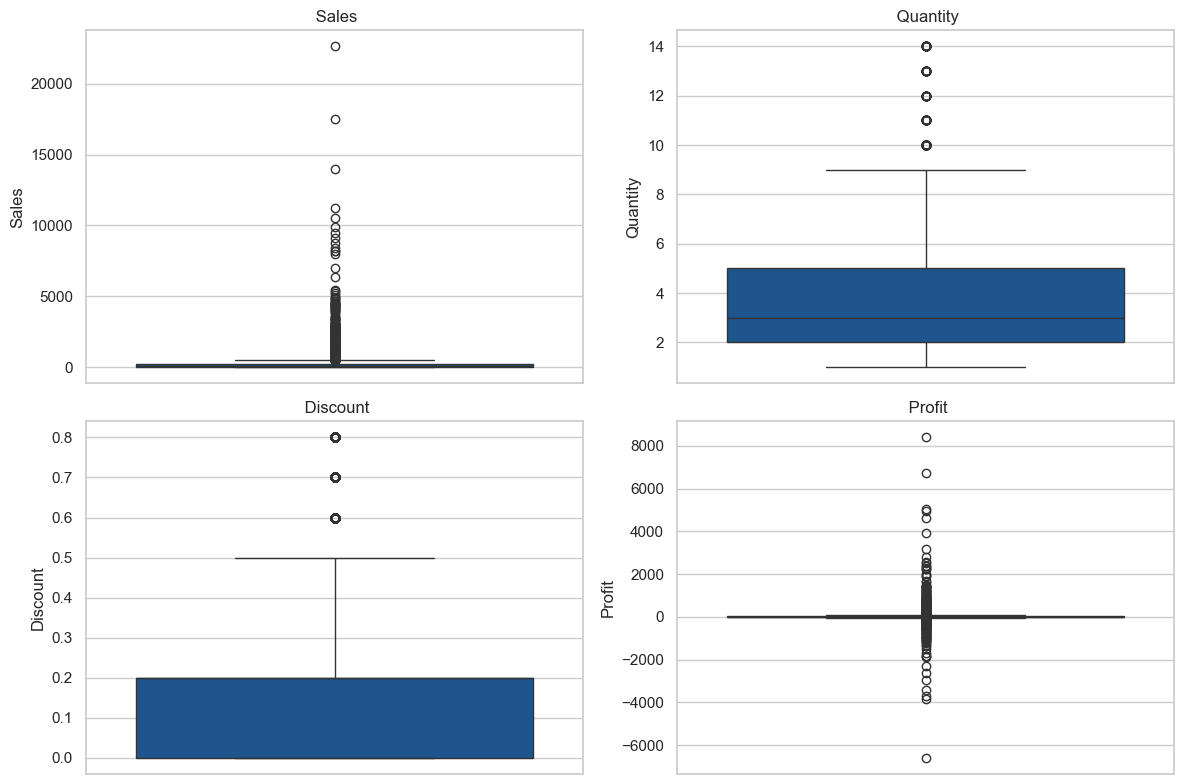

In [12]:
# Identifying the columns
kolom = ['Sales', 'Quantity', 'Discount', 'Profit']

plt.figure(figsize=(12,8))

for i, col in enumerate(kolom, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f' {col}')

plt.tight_layout()
plt.show()


1. The Sales variable exhibits a right-skewed distribution, indicating that most transactions generate relatively low sales, while a few high-value transactions account for a significant portion of total sales.
2. Most customers purchase between 2 and 5 units per transaction, while high-volume purchases are relatively rare. This indicates that sales are primarily driven by small to medium-sized orders
3. Most transactions receive little to no discount, while high discount rates are applied to only a small number of transactions. This suggests that discounts are used selectively rather than as a standard pricing strategy.
4. Profit is highly variable, with both positive and negative outliers. While most transactions generate modest profits, a small number of transactions contribute exceptionally high profits or significant losses.


# Shipping Mode

In [13]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5955
Second Class      1943
First Class       1537
Same Day           542
Name: count, dtype: int64

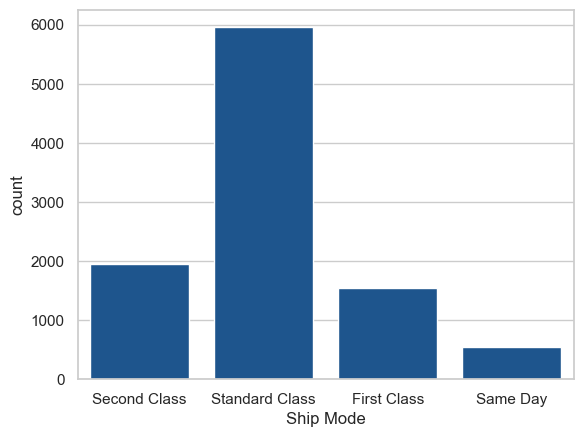

In [14]:
sns.countplot(x='Ship Mode', data=df)
plt.show()

Standard Class is the most frequently used shipping method, accounting for the majority of orders, while Same Day is the least utilized. This indicates that customers generally prefer standard shipping over premium delivery options.

# Kind of Segment

In [15]:
df['Segment'].value_counts()

Segment
Consumer       5183
Corporate      3015
Home Office    1779
Name: count, dtype: int64

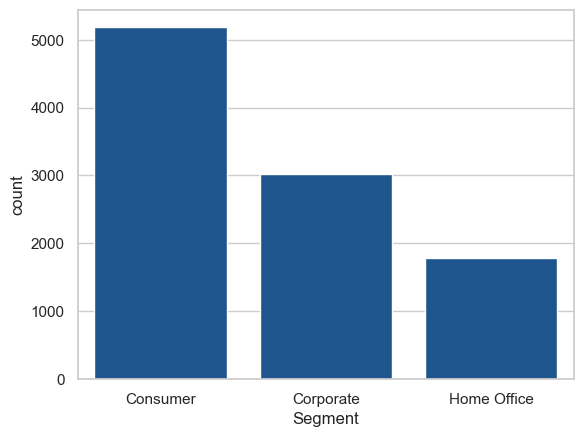

In [16]:
sns.countplot(x='Segment', data=df)
plt.show()

The Consumer segment accounts for the largest share of orders, followed by Corporate, while Home Office represents the smallest segment. This indicates that the retail business is primarily driven by individual consumers

# Category of the items

In [17]:
df['Category'].value_counts()

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

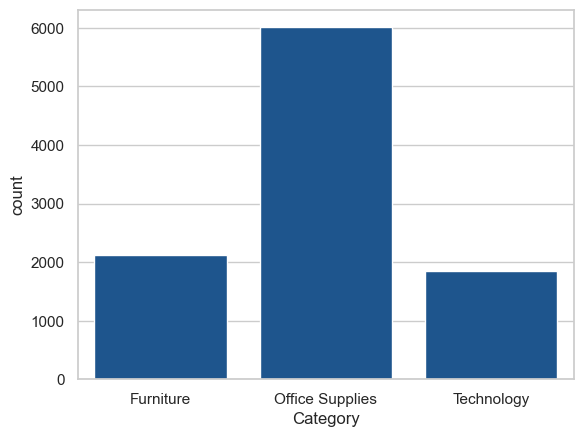

In [18]:
sns.countplot(x='Category', data=df)
plt.show()

Office Supplies is the most frequently purchased category, indicating higher transaction volume compared to Furniture and Technology

# Sub-Category of the items

In [19]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

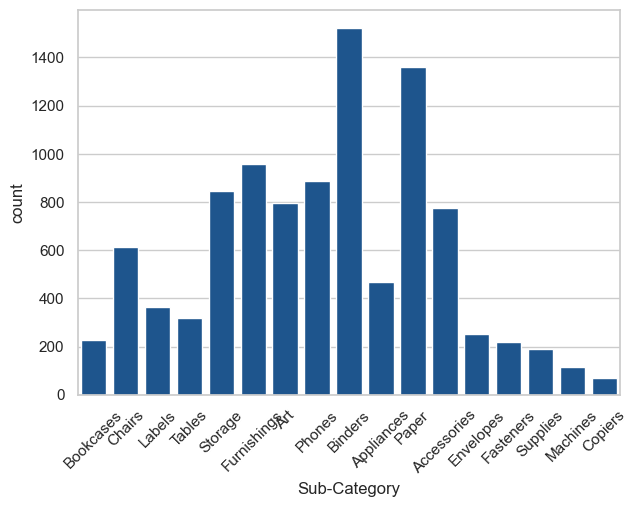

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Sub-Category', data=df)
plt.xticks(rotation=45)  
plt.show()

Transaction volume varies considerably across sub-categories. Binders and Paper dominate order frequency, while Copiers and Machines represent niche products with relatively low purchase activity

## Do higher sales always lead to higher profits?

<Axes: xlabel='Sales', ylabel='Profit'>

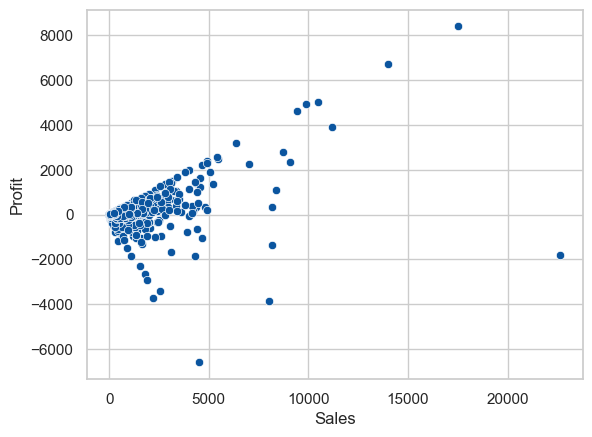

In [21]:
sns.scatterplot(x='Sales', y='Profit', data=df)

Sales and profit show a generally positive relationship; however, higher sales do not always result in higher profits. Several high-sales transactions generate low or even negative profits, indicating that factors such as discounts or product costs may reduce profitability.

## Does discounts affect profit?"

<Axes: xlabel='Discount', ylabel='Profit'>

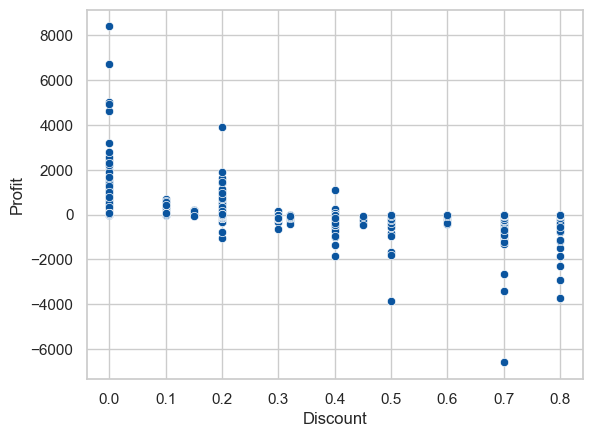

In [22]:
sns.scatterplot(x='Discount', y='Profit', data=df)

The analysis suggests a negative relationship between discount and profit. As discount rates increase, profitability generally decreases, with high-discount transactions more likely to generate low or negative profits

## Which category generates the highest profit?

In [23]:
st_Category = df.groupby(["Category"])["Profit"].sum().nlargest()
print(st_Category)

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


<Axes: xlabel='Category', ylabel='Profit'>

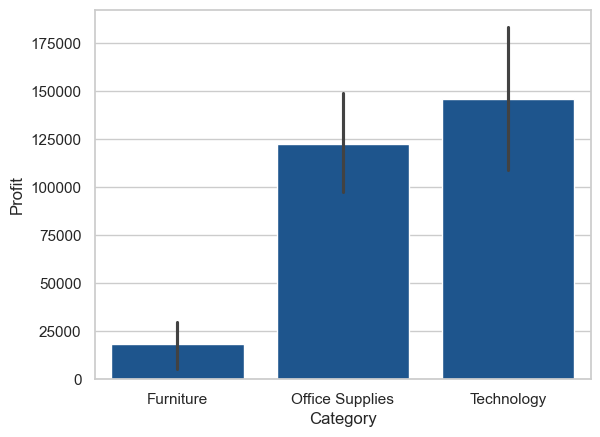

In [24]:
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)

## Which products always make Profit and loss?

In [25]:
profit_loss = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

print(profit_loss)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Storage        21278.8264
Chairs         26567.1278
Binders        30228.0003
Paper          33944.2395
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


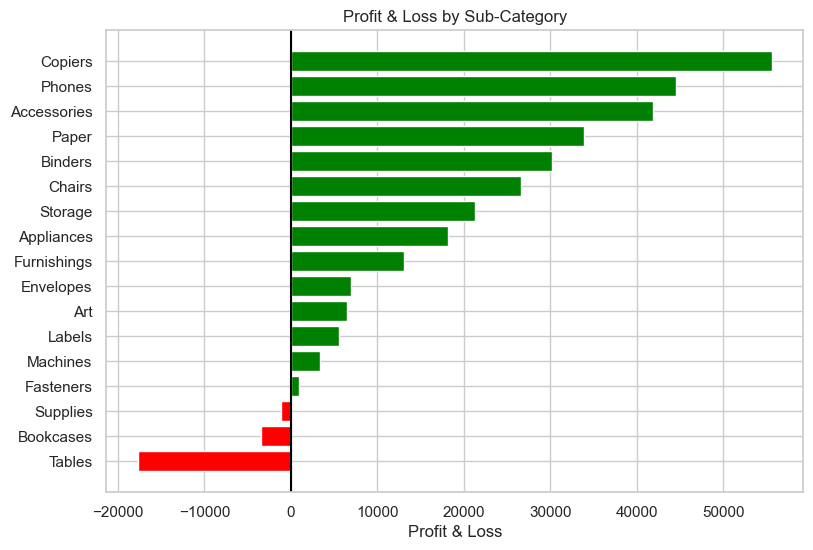

In [26]:
profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

colors = ["red" if x < 0 else "green" for x in profit]

plt.figure(figsize=(9,6))

plt.barh(
    profit.index,
    profit.values,
    color=colors
)

plt.axvline(0, color="black")
plt.title("Profit & Loss by Sub-Category")
plt.xlabel("Profit & Loss")
plt.show()

Out of 17 sub-categories, 14 generate a positive profit, while 3 generate a loss. Tables has the largest loss, whereas Copiers generates the highest profit. This shows that the company's overall profitability is strongly influenced by the performance of a few key sub-categories. Therefore, the loss-making sub-categories should be prioritized for further analysis and improvement.

## Which category has the highest sales?

In [27]:
st_Category = df.groupby(["Category"])["Sales"].sum().nlargest()
print(st_Category)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


<Axes: xlabel='Category', ylabel='Sales'>

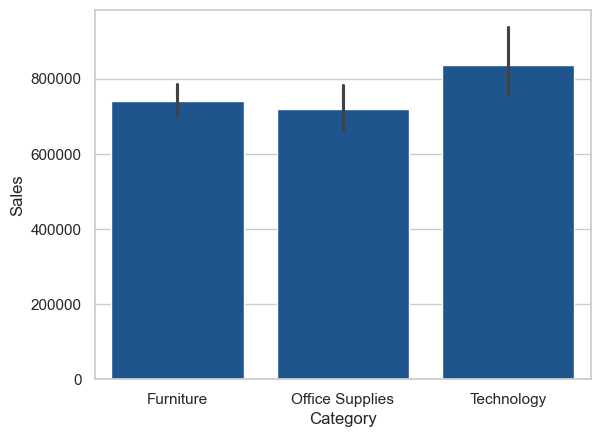

In [28]:
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)

Technology had the highest total sales, showing strong customer demand

## Which customer segment has the highest sales?

In [29]:
st_Segment = df.groupby(["Segment"])["Sales"].sum().nlargest()
print(st_Segment)

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


<Axes: xlabel='Segment', ylabel='Sales'>

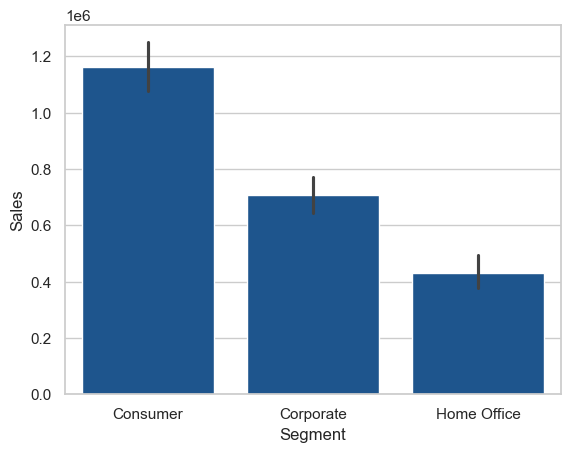

In [30]:
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum)

The consumer generated the highest total sales, making it the best-performing segment

## Which state generates the highest profit?

In [31]:
st_profit = df.groupby(["State"])["Profit"].sum().nlargest(20)
print(st_profit)

State
California       76330.7891
New York         74015.4622
Washington       33368.2375
Michigan         24428.0903
Virginia         18597.9504
Indiana          18382.9363
Georgia          16250.0433
Kentucky         11199.6966
Minnesota        10823.1874
Delaware          9977.3748
New Jersey        9772.9138
Wisconsin         8401.8004
Rhode Island      7285.6293
Maryland          7031.1788
Massachusetts     6785.5016
Missouri          6436.2105
Alabama           5786.8253
Oklahoma          4853.9560
Arkansas          4008.6871
Connecticut       3511.4918
Name: Profit, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

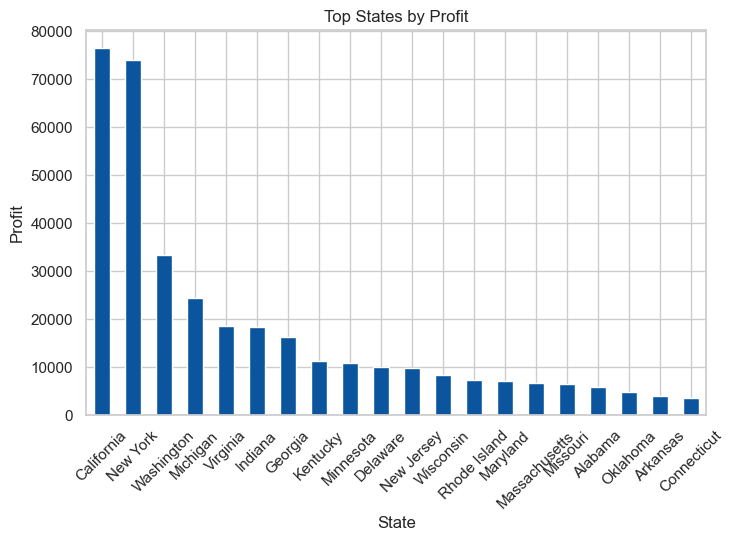

In [32]:
plt.figure(figsize=(8, 5))
st_profit.plot.bar(rot=45)
plt.title('Top States by Profit')
plt.xlabel('State')
plt.ylabel('Profit')
plt.show

Profit is concentrated in California and New York, while the remaining states contribute considerably less. This suggests that strengthening performance in lower-profit states could improve overall profitability.

## Corelation & Heatmap

In [33]:
cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df[cols].corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


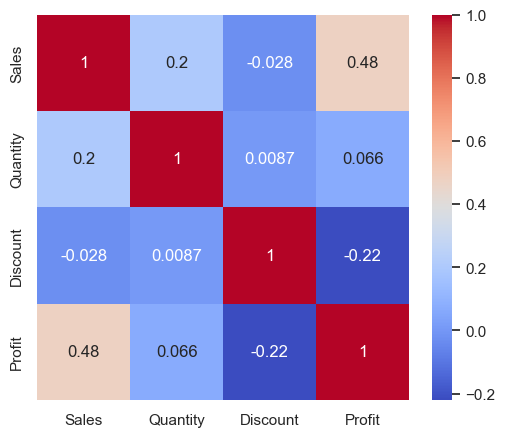

In [34]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
if 'Postal Code' in corr.columns:
    corr = corr.drop(columns=['Postal Code'], index=['Postal Code'])
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Which category generates the highest profit across different regions?

In [35]:
st_category_region = (
    df.groupby(["Category", "Region"])["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(st_category_region)

Category         Region 
Office Supplies  West       52527.6286
Technology       East       47462.0351
                 West       44303.6496
Office Supplies  East       40986.0495
Technology       Central    33697.4320
                 South      19991.8314
Office Supplies  South      19986.3928
Furniture        West       11498.5297
Office Supplies  Central     8864.5899
Furniture        South       6771.2061
                 East        3058.2246
                 Central    -2906.1467
Name: Profit, dtype: float64


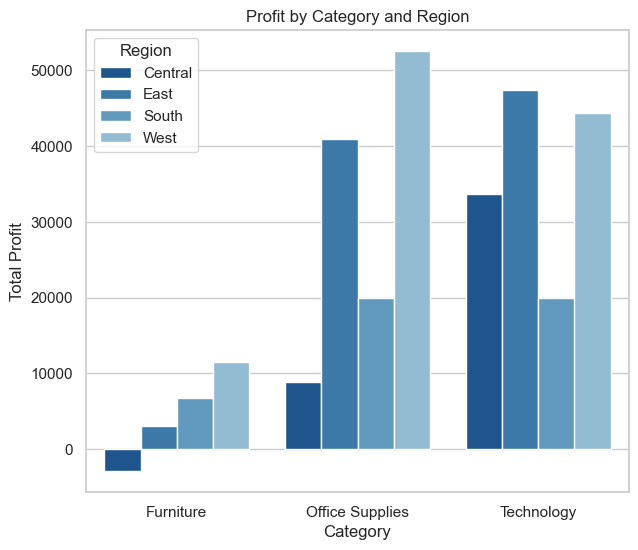

In [36]:
profit_region = (
    df.groupby(['Category', 'Region'])['Profit']
      .sum()
      .reset_index()
)

plt.figure(figsize=(7,6))
sns.barplot(
    data=profit_region,
    x='Category',
    y='Profit',
    hue='Region'
)

plt.title('Profit by Category and Region')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.show()

The West and East regions contribute the highest profits, driven mainly by the Technology and Office Supplies categories. Meanwhile, Furniture generates relatively low profits and records losses in the Central region, highlighting an opportunity to improve pricing and discount strategies

## Which Customer Segment Generates the Highest Sales and Profit?

In [37]:
segment_sales_profit = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

print(segment_sales_profit)

                    Sales       Profit
Segment                               
Consumer     1.160833e+06  134007.4413
Corporate    7.060701e+05   91954.9798
Home Office  4.292927e+05   60279.0015


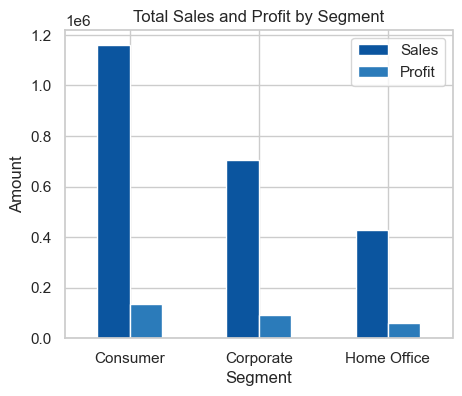

In [38]:
segment_sales_profit = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

segment_sales_profit.plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Total Sales and Profit by Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

The Consumer segment contributes the highest sales and profit, followed by Corporate and Home Office. This indicates that the Consumer segment is the company's most profitable customer group and should remain a key focus for sales and marketing strategies

## Does Shipping Mode Affect Sales & Profitability?

In [39]:
Ship_Mode_sales_profit = (
    df.groupby("Ship Mode")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

print(Ship_Mode_sales_profit)

                       Sales       Profit
Ship Mode                                
Standard Class  1.357316e+06  163969.2280
Second Class    4.591770e+05   57446.6516
First Class     3.513805e+05   48953.6561
Same Day        1.283217e+05   15871.8869


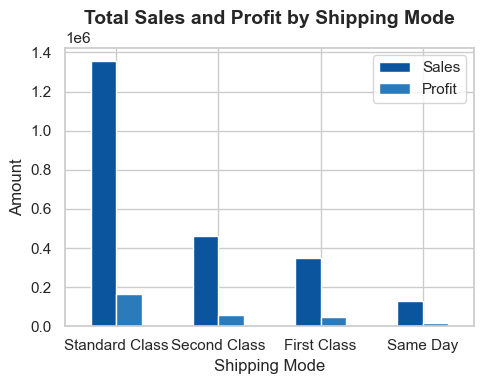

In [40]:
ship_summary = (
    df.groupby("Ship Mode")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

# Plot bar grafik
ax = ship_summary.plot(kind="bar", figsize=(5,4 ))

plt.title("Total Sales and Profit by Shipping Mode", fontsize=14, fontweight="bold")
plt.xlabel("Shipping Mode")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Standard Class generates the highest sales and profit, making it the most profitable shipping mode. In contrast, Same Day contributes the lowest sales and profit, suggesting that faster shipping is used less frequently and has a smaller impact on overall profitability

## Key Insights from EDA


1. Sales and Profit are right-skewed, with a few transactions having extremely high values (outliers). Most transactions have relatively low Sales,  Profit, and Discount values.
2. Discount is negatively correlated with Profit (≈ -0.22). Higher discounts are associated with a greater likelihood of lower or even negative profit.
3. Sales has a moderate positive correlation with Profit (≈ 0.48), indicating that higher sales do not always result in higher profit.
4. Tables, Bookcases, and Supplies are the largest loss-making sub-categories, while Copiers, Phones, and Accessories generate the highest profits.
5. Profitability varies across the combination of Category and Region. Although Furniture is profitable overall, it records losses in the Central region.
6. The Consumer segment accounts for the highest number of transactions, and Standard Class is the most frequently used shipping mode. However, their high total Sales and Profit are likely driven by transaction volume rather than higher profit per transaction.


## Data splitting
  - Data Train = 60%
  - Data Validation = 20%
  - Data Test = 20%

In [41]:
df.shape

(9977, 13)

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_valid = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [44]:
df_train.shape, df_valid.shape, df_test.shape

((5985, 13), (1996, 13), (1996, 13))

In [45]:
5985/9977, 1996/9977, 1996/9977

(0.5998797233637366, 0.20006013831813171, 0.20006013831813171)

## Preprocessing

In [46]:
X = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Category",
        "Sub-Category",
        "Segment",
        "Region",
        "Ship Mode"
    ]
]

y = df["Profit"]

In [47]:
X.head()

,Sales,Quantity,Discount,Category,Sub-Category,Segment,Region,Ship Mode
0,261.9600,2,0.00,Furniture,Bookcases,Consumer,South,Second Class
1,731.9400,3,0.00,Furniture,Chairs,Consumer,South,Second Class
2,14.6200,2,0.00,Office Supplies,Labels,Corporate,West,Second Class
3,957.5775,5,0.45,Furniture,Tables,Consumer,South,Standard Class
4,22.3680,2,0.20,Office Supplies,Storage,Consumer,South,Standard Class


In [49]:
def add_features(data):
    data = data.copy()
    data["Sales_x_Discount"] = data["Sales"] * data["Discount"]
    data["Log_Sales"] = np.log1p(data["Sales"])
    return data

import numpy as np

df_train_fe = add_features(df_train)
df_valid_fe = add_features(df_valid)
df_test_fe  = add_features(df_test)

df_train_fe[["Sales", "Discount", "Sales_x_Discount", "Log_Sales"]].head()

,Sales,Discount,Sales_x_Discount,Log_Sales
4580,239.70,0.0,0.000,5.483551
4304,63.92,0.0,0.000,4.173156
1352,183.96,0.2,36.792,5.220140
2364,160.32,0.0,0.000,5.083390
6601,239.84,0.0,0.000,5.484133


In [50]:
numeric_features = ["Sales", "Quantity", "Discount", "Sales_x_Discount", "Log_Sales"]
categorical_features = ["Category", "Sub-Category", "Segment", "Region", "Ship Mode"]

feature_cols = numeric_features + categorical_features

X_train = df_train_fe[feature_cols]
y_train = df_train_fe["Profit"]

X_valid = df_valid_fe[feature_cols]
y_valid = df_valid_fe["Profit"]

X_test = df_test_fe[feature_cols]
y_test = df_test_fe["Profit"]

X_train.head()

,Sales,Quantity,Discount,Sales_x_Discount,Log_Sales,Category,Sub-Category,Segment,Region,Ship Mode
4580,239.70,6,0.0,0.000,5.483551,Technology,Accessories,Corporate,South,Standard Class
4304,63.92,4,0.0,0.000,4.173156,Furniture,Furnishings,Consumer,West,Second Class
1352,183.96,5,0.2,36.792,5.220140,Technology,Phones,Corporate,West,Standard Class
2364,160.32,2,0.0,0.000,5.083390,Office Supplies,Appliances,Home Office,South,Standard Class
6601,239.84,8,0.0,0.000,5.484133,Furniture,Chairs,Corporate,East,Standard Class


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [52]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed  = preprocessor.transform(X_test)

print(X_train_processed.shape, X_valid_processed.shape, X_test_processed.shape)

(5985, 36) (1996, 36) (1996, 36)


In [53]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names[:15]) 

['num__Sales' 'num__Quantity' 'num__Discount' 'num__Sales_x_Discount'
 'num__Log_Sales' 'cat__Category_Furniture'
 'cat__Category_Office Supplies' 'cat__Category_Technology'
 'cat__Sub-Category_Accessories' 'cat__Sub-Category_Appliances'
 'cat__Sub-Category_Art' 'cat__Sub-Category_Binders'
 'cat__Sub-Category_Bookcases' 'cat__Sub-Category_Chairs'
 'cat__Sub-Category_Copiers']


In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train_processed, y_train)

y_pred_valid = model.predict(X_valid_processed)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
print("RMSE:", rmse)
print("MAE :", mean_absolute_error(y_valid, y_pred_valid))
print("R2  :", r2_score(y_valid, y_pred_valid))

RMSE: 144.0560360610157
MAE : 44.34242748479448
R2  : 0.7685370176895174


In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_valid_processed)

rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
print("RMSE:", rmse_rf)
print("MAE :", mean_absolute_error(y_valid, y_pred_rf))
print("R2  :", r2_score(y_valid, y_pred_rf))

RMSE: 208.98684930518786
MAE : 27.871735878666513
R2  : 0.5128569160894768


In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=1)
gb_model.fit(X_train_processed, y_train)

y_pred_gb = gb_model.predict(X_valid_processed)

print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred_gb)))
print("MAE :", mean_absolute_error(y_valid, y_pred_gb))
print("R2  :", r2_score(y_valid, y_pred_gb))

RMSE: 173.51296258567936
MAE : 28.556331465785647
R2  : 0.6641986219094507


In [59]:
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(15))

num__Sales_x_Discount          0.253819
num__Log_Sales                 0.248241
num__Sales                     0.233595
num__Discount                  0.091399
num__Quantity                  0.021228
cat__Segment_Consumer          0.019804
cat__Sub-Category_Binders      0.018029
cat__Sub-Category_Copiers      0.013680
cat__Sub-Category_Supplies     0.013486
cat__Sub-Category_Machines     0.011127
cat__Category_Furniture        0.009254
cat__Ship Mode_Second Class    0.006117
cat__Category_Technology       0.005995
cat__Ship Mode_First Class     0.005908
cat__Region_South              0.005075
dtype: float64


In [60]:
df_train["Profit"].describe()
df_train["Profit"].sort_values().head(10)

4991   -2929.4845
3151   -2639.9912
5310   -2287.7820
9639   -1862.3124
2697   -1811.0784
27     -1665.0522
2928   -1306.5504
7898   -1237.8462
8640   -1141.4700
4355   -1065.3720
Name: Profit, dtype: float64

In [61]:
df_train[df_train["Profit"] < -1000][["Sales", "Quantity", "Discount", "Category", "Sub-Category", "Profit"]]

,Sales,Quantity,Discount,Category,Sub-Category,Profit
5310,1525.188,6,0.8,Office Supplies,Binders,-2287.7820
3151,1799.994,2,0.7,Technology,Machines,-2639.9912
2697,22638.480,6,0.5,Technology,Machines,-1811.0784
4355,1598.058,7,0.7,Office Supplies,Binders,-1065.3720
2928,1633.188,4,0.7,Office Supplies,Binders,-1306.5504
9639,4297.644,13,0.4,Furniture,Tables,-1862.3124
8640,760.980,5,0.8,Office Supplies,Binders,-1141.4700
27,3083.430,7,0.5,Furniture,Bookcases,-1665.0522
1803,4663.736,7,0.2,Office Supplies,Supplies,-1049.3406
4991,1889.990,5,0.8,Office Supplies,Binders,-2929.4845


In [62]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 10]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=1), param_grid, cv=3, scoring="r2", n_jobs=-1)
grid_rf.fit(X_train_processed, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
0.6274092130491161


In [63]:
from sklearn.linear_model import HuberRegressor

huber_model = HuberRegressor(max_iter=1000)
huber_model.fit(X_train_processed, y_train)
y_pred_huber = huber_model.predict(X_valid_processed)

print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred_huber)))
print("MAE :", mean_absolute_error(y_valid, y_pred_huber))
print("R2  :", r2_score(y_valid, y_pred_huber))

RMSE: 156.10572338161617
MAE : 32.539672967394026
R2  : 0.7281957293389936


In [66]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 6.3 MB/s eta 0:00:11
   - -------------------------------------- 2.6/69.5 MB 6.9 MB/s eta 0:00:10
   - -------------------------------------- 3.4/69.5 MB 5.9 MB/s eta 0:00:12
   -- ------------------------------------- 4.7/69.5 MB 6.1 MB/s eta 0:00:11
   --- ------------------------------------ 5.8/69.5 MB 6.0 MB/s eta 0:00:11
   --- ------------------------------------ 6.3/69.5 MB 5.4 MB/s eta 0:00:12
   --- ------------------------------------ 6.8/69.5 MB 4.9 MB/s eta 0:00:13
   ---- ----------------------------------- 7.3/69.5 MB 4.6 MB/s eta 0:00:14
   ---- ----------------------------------- 7.9/69.5 MB 4.3 MB/s eta 0:00:15
   ---- ----------------------------------- 8.4/69.5 MB 4.1 MB/s eta 0:00:16
   ----- ---------------------------------- 8.9/69.5 MB 3.9 MB/s eta 0:00:16
   ----- ---------------------------------- 9.4/69.5 MB 3.8 MB/s eta 0:00:16
   ---

In [67]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=1)
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_valid_processed)

print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred_xgb)))
print("MAE :", mean_absolute_error(y_valid, y_pred_xgb))
print("R2  :", r2_score(y_valid, y_pred_xgb))

RMSE: 205.94813147156628
MAE : 27.949565973332213
R2  : 0.5269202745903196


In [68]:
mask = y_valid > -1000
print("R2 (tanpa outlier ekstrem):", r2_score(y_valid[mask], y_pred_valid[mask]))

R2 (tanpa outlier ekstrem): 0.8199217927790158


In [70]:
y_pred_test = huber_model.predict(X_test_processed)

print("=== HASIL FINAL DI TEST SET (Huber Regressor) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("MAE :", mean_absolute_error(y_test, y_pred_test))
print("R2  :", r2_score(y_test, y_pred_test))

=== HASIL FINAL DI TEST SET (Huber Regressor) ===
RMSE: 159.35520621391365
MAE : 29.973125543703404
R2  : 0.7158803899058994


In [72]:
y_pred_test_lr = model.predict(X_test_processed)

print("=== HASIL FINAL DI TEST SET (Linear Regression) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_lr)))
print("MAE :", mean_absolute_error(y_test, y_pred_test_lr))
print("R2  :", r2_score(y_test, y_pred_test_lr))

=== HASIL FINAL DI TEST SET (Linear Regression) ===
RMSE: 150.67742223605842
MAE : 41.367224076052956
R2  : 0.7459816678359779


## Predicted vs Actual plot

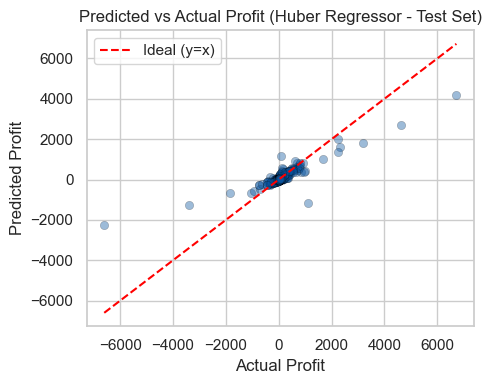

In [74]:
y_pred_test_huber = huber_model.predict(X_test_processed)

plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred_test_huber, alpha=0.4, edgecolor="k", linewidth=0.3)

# Garis diagonal ideal (prediksi = aktual)
min_val = min(y_test.min(), y_pred_test_huber.min())
max_val = max(y_test.max(), y_pred_test_huber.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal (y=x)")

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Predicted vs Actual Profit (Huber Regressor - Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

Predicted vs Actual: ideally, the points should stick closely along the red dashed line. If there are points that deviate significantly, those are most likely the extreme loss transactions (outliers) that we discussed earlier

## Residual Plot

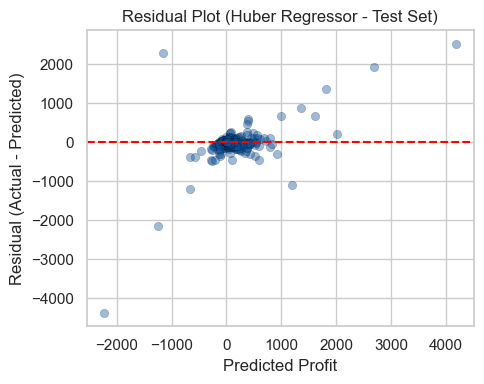

In [77]:
residuals = y_test - y_pred_test_huber

plt.figure(figsize=(5, 4))
plt.scatter(y_pred_test_huber, residuals, alpha=0.4, edgecolor="k", linewidth=0.3)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Profit")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Huber Regressor - Test Set)")
plt.tight_layout()
plt.show()

Residual plot: ideally, the points are randomly scattered around the 0 line (without forming a funnel or curved pattern). If there is a widening pattern (heteroscedasticity), it indicates that the model is less optimal within a certain range of values

## Residual Distribution

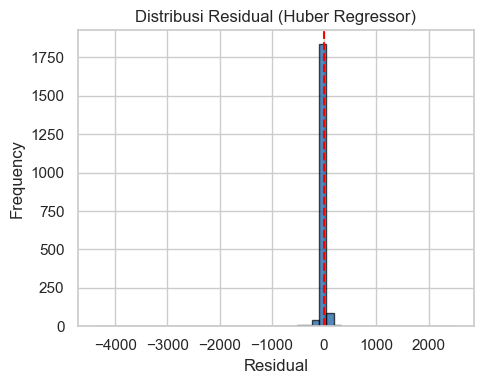

In [79]:
plt.figure(figsize=(5, 4))
plt.hist(residuals, bins=50, edgecolor="k", alpha=0.7)
plt.axvline(x=0, color="red", linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribusi Residual (Huber Regressor)")
plt.tight_layout()
plt.show()

In [81]:
import joblib

joblib.dump(huber_model, "huber_model_final.pkl")
joblib.dump(preprocessor, "preprocessor_final.pkl")

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [83]:
loaded_model = joblib.load("huber_model_final.pkl")
loaded_preprocessor = joblib.load("preprocessor_final.pkl")

## Conclusion

### Analyze Goal
This project analyzes the sales and profit performance of a retail company (Sample Superstore dataset) to identify the key factors affecting profitability, and builds a machine learning model to predict transaction-level Profit based on Sales, Discount, Quantity, and categorical attributes (Category, Sub-Category, Segment, Region, Ship Mode)

### Key Findings from EDA
1. **Sales and Profit are right-skewed** — most transactions generate modest values, while a small number of high-value transactions and extreme losses dominate the tails of the distribution.
2. **Discount is negatively correlated with Profit (≈ -0.22)** — higher discount rates are strongly associated with lower or negative profit.
3. **Sales has only a moderate positive correlation with Profit (≈ 0.48)** — higher sales do not automatically translate into higher profit, since discounting and product cost structure can erode margins.
4. **Sub-category performance is uneven** — Tables, Bookcases, and Supplies are the largest loss-making sub-categories, while Copiers, Phones, and Accessories are the most profitable.
5. **Profitability varies by Category × Region** — Furniture is profitable overall but loses money specifically in the Central region.
6. **Consumer segment and Standard Class shipping dominate transaction volume**, but this appears to be driven by volume rather than higher profit margin per transaction.

### Modeling Approach
- Data was split 60% train / 20% validation / 20% test.
- Feature engineering added `Sales_x_Discount` (interaction term) and `Log_Sales` (to address skewness), on top of the original numeric and categorical features.
- Preprocessing used `StandardScaler` for numeric features and `OneHotEncoder` for categorical features, combined in a single `ColumnTransformer`, fit only on the training set to avoid data leakage.
- Six regression approaches were compared: Linear Regression, Random Forest (default & tuned via GridSearchCV), Gradient Boosting, Huber Regressor, and XGBoost.
- A log-transform of the target (`sign(y) * log1p(|y|)`) was also tested to handle extreme profit outliers, but it failed badly due to the exponential blow-up of errors during inverse transformation — a useful negative result showing that not every theoretically appealing transform works in practice.

### Model Comparison (Test Set)
| Model | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 150.68 | 41.37 | 0.7460 |
| **Huber Regressor (final model)** | 159.36 | 29.97 | 0.7159 |

Tree-based models (Random Forest, Gradient Boosting, XGBoost) underperformed the linear models, most likely because the relatively small dataset size caused them to overfit to the extreme-loss outliers rather than generalize.


### Final Model Selection: Huber Regressor
The **Huber Regressor** was selected as the final model because it is explicitly designed to be robust to outliers, which matches the nature of this dataset (a small number of transactions with extreme losses driven by very high discounts). While its R² is slightly lower than plain Linear Regression, its MAE is substantially better — meaning it produces more accurate predictions for the majority of "normal" transactions, which is more useful for everyday business decision-making than being biased toward a handful of extreme cases.


### Business Recommendations
1. **Review discounting policy** for Tables, Bookcases, Binders, and Machines — these consistently show the strongest link between high discounts and heavy losses.
2. **Investigate Furniture performance in the Central region** specifically, since it is profitable elsewhere but loses money there.
3. **Use the interaction between Sales and Discount** (not Sales alone) as a leading indicator of transaction profitability when setting pricing/discount thresholds.
4. The final model and preprocessing pipeline have been saved (`huber_model_final.pkl`, `preprocessor_final.pkl`) and can be reused to score new transactions without retraining.


### Limitations & Future Work
- The dataset is relatively small (~10k rows after removing duplicates), which limits the ability of complex tree-based/ensemble models to outperform simpler linear approaches.
- Extreme-loss transactions remain the hardest cases to predict accurately; a dedicated model or business rule for high-discount transactions could be explored.
- Future work could include time-based features (order date, shipping duration) if available, and further hyperparameter tuning of Gradient Boosting/XGBoost with outlier-aware loss functions (e.g., Huber loss objective in XGBoost)